# 2025년 06월 04일 수요일 (28일차)  



<br><br><br>

# 📜 목차  
- **선형 자료구조**  
  - [**queue**]  
    - Linear Queue (선형 큐)  
    - Circular Queue (원영 큐 or 환영큐)  
    - Queue class  
  <br>
  - [**Doubly Linked List**] 파이썬으로 `다중 연결 리스트` 구현하기  
  <br><br>
- **알고리즘**  
  - 재귀호출  
    - 피보나치 수열  
  - 정렬  
    - Selection Sort  

<br><br><br><br>

---

# 🟩 자료구조(Data Structure) 2  


<br><br><br><br>

--- 

# 🟩 [**Queue**] 파이썬으로 `큐` 구현하기  

- 비유: 줄 서기  
  - 편의점 계산대 줄을 생각해 보세요: 먼저 온 사람이 먼저 계산하고 나감 / 나중에 온 사람은 그 뒤에 줄 서서 기다림  
<br>

- 특징  
  - 선입선출 (FIFO: First In, First Out)  
  - 먼저 들어온게 먼저 나가는 일부 메모리 공간을 잘라서 우리가 키보드를 누르면 그 값이 버퍼라는 공강에 먼저 들어갔다가 엔터키 누르면 그때 메모리로 들어간다.  
  - 데이터를 모아두었다가 한번에 처리하는 방식  
<br>

- 종류  
  - 선형 큐 (Linear Queue)  
  - 원형 큐 (Circular Queue)  or 환형 큐  
  - 덱 (Deque) or 양방향 큐  
  - 우선순위 큐 (Priority Queue)  
<br>

- 명령어 형태  
  - put - 큐에 데이터 넣는 연산  
  - get - 큐에서 데이터 가져오기 연산  
  - is_full - 큐가 차면 True 아니면 False  
  - is_empty - 큐가 비었는지 True 아니면 False  
  - peek - 큐의 맨처음값 하나 확인하는 용도  


#### 큐 이해 사진  
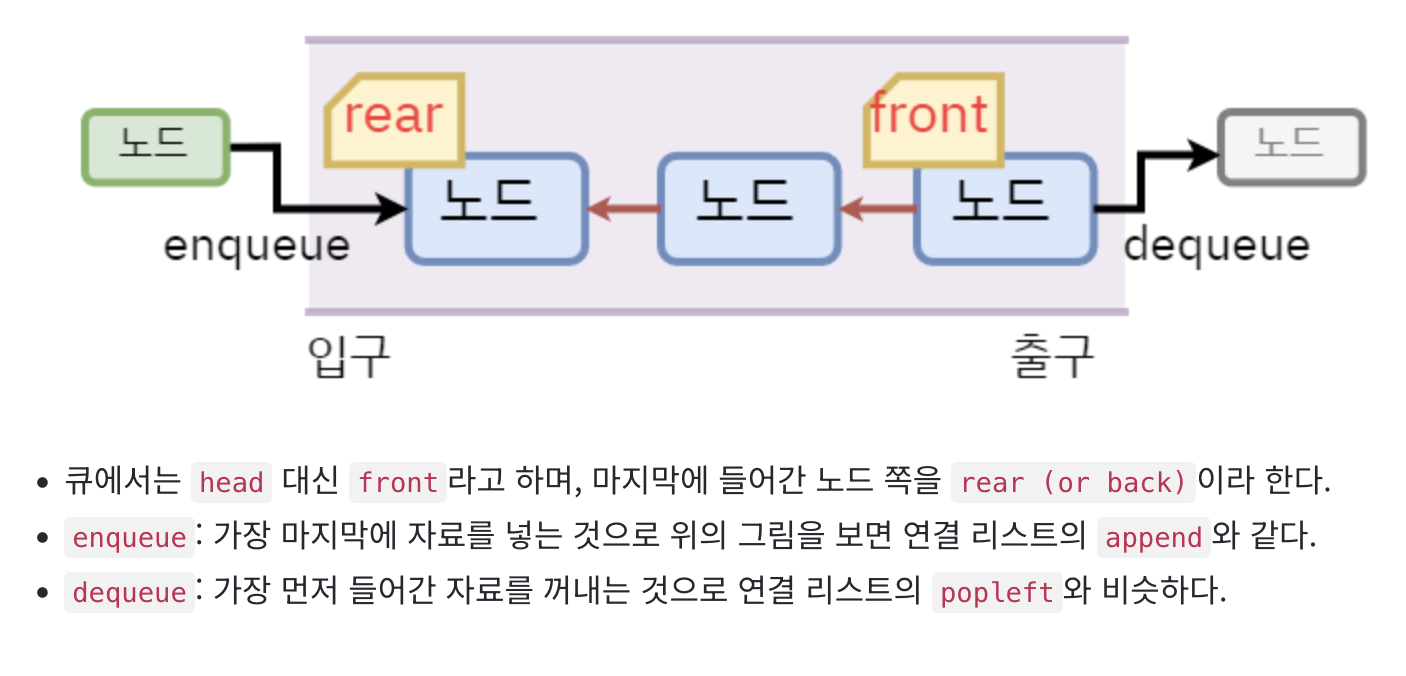  
사진 출처 : https://wikidocs.net/192523  


### 🟡 Linear Queue (선형 큐)  
| 용어      | 설명                                      |  
|-----------|-------------------------------------------|
| 큐 (Queue) | 선입선출(FIFO) 방식의 선형 자료구조         |  
| Enqueue   | 데이터를 큐에 추가하는 연산 (뒤에 넣음)      |  
| Dequeue   | 데이터를 큐에서 제거하는 연산 (앞에서 뺌)    |  
| Front     | 큐의 가장 앞에 있는 데이터 (곧 나갈 데이터)  |  
| Rear      | 큐의 가장 뒤에 있는 데이터 (최근 들어온 데이터) |  


```markdown
`큐의 흐름 (선입선출)`  

   [Front]                  [Rear]  
      ↓                       ↓  
   ┌───────┬───────┬───────┬───────┐  
   │   1   │   2   │   3   │   4   │  
   └───────┴───────┴───────┴───────┘  
     ↑ (dequeue)         ↑ (enqueue)  
```
- 개념  
   - Front = 어디에서 꺼낼 것인지  
   - Rear = 어디에 저장할 것인지  
   - 




### 🟡 Circular Queue (원영 큐 or 환영큐)  


#### ⚫️ 왜 `선형큐 or 환영큐`를 사용하는가?  
  **선형 큐(Linear Queue)**는 데이터를 enqueue → dequeue 하다 보면 앞에 공간이 생겨도 다시 사용하지 못하는 문제가 생깁니다! 그래서 바로 원형큐를 공부하는 것이다!  

```python
배열 크기: 5  

초기 상태: [ _, _, _, _, _ ]  
enqueue 3개: [ 1, 2, 3, _, _ ]  
dequeue 2개: [ _, _, 3, _, _ ] ← 앞 공간이 비었지만 못 씀  
enqueue 2개: [ _, _, 3, 4, 5 ]  
더 이상 enqueue 불가!  
```

원형 큐는 배열의 처음과 끝이 연결되어 있다고 간주하여, 배열의 끝에 도달해도 앞부분에 빈 공간이 있다면 그곳에 데이터를 저장할 수 있게 합니다. 마치 원형 트랙과 같습니다.  



#### 원형큐 참고 사진  
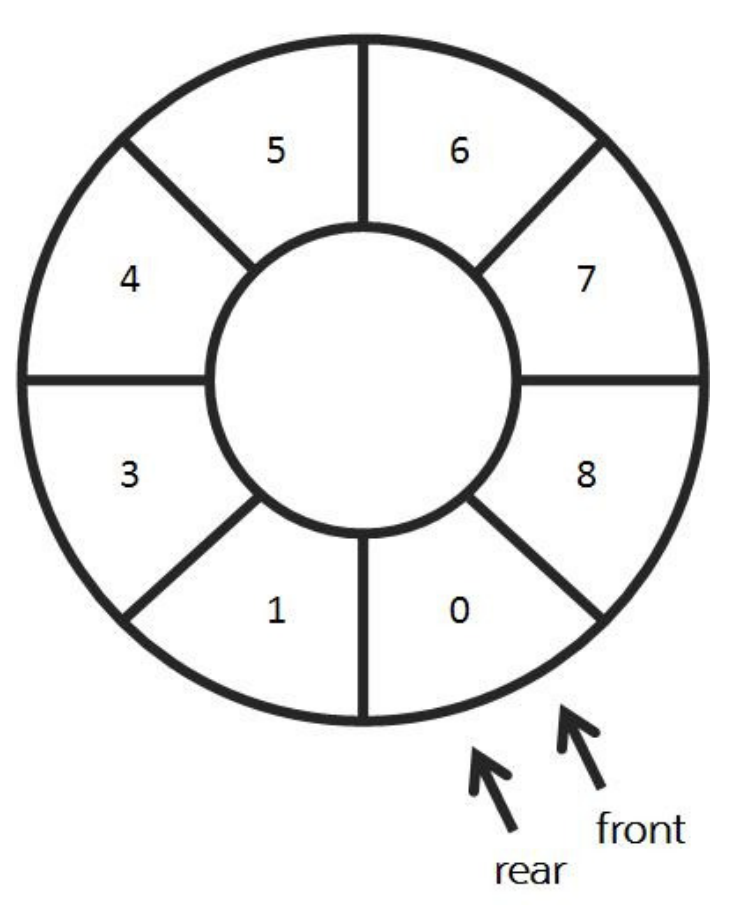  
사진 출처 : https://mengu.tistory.com/110  

### 🟡 Circular Queue class로 만들기  

In [9]:

class MyQueue:
    def __init__(self, size=10):
        # MyQueue 클래스의 생성자입니다. 큐의 최대 크기(용량)를 설정합니다.
        if size < 10: # 큐의 최소 크기를 10으로 강제합니다.
            size = 10
        self.size = size # 큐의 최대 크기를 저장하는 인스턴스 변수입니다.

        # self.queue는 큐의 실제 데이터 요소들이 저장될 공간입니다.
        # self.size만큼의 길이를 가진 리스트를 생성하며, 모든 요소를 None으로 초기화합니다.
        # 이는 MyQueue가 미리 정해진 고정된 크기(self.size)를 가진 배열(파이썬 리스트)로 구현되었음을 의미합니다.
        self.queue = [None] * self.size   # 해당 size 길이를 가진 배열인데 모든 초기값은 None이다.

        # self.front와 self.rear는 큐의 실제 데이터가 저장된 self.queue 리스트의 **인덱스를 가리키는 숫자(정수)**입니다.
        # 두 인덱스는 0으로 초기화됩니다.
        # 이 구현에서 self.front와 self.rear는 **절대로 음수가 될 일이 없으며**, 항상 0 이상의 정수 값을 유지합니다 [대화 내용].
        self.front = 0      # 큐에서 가장 먼저 나올(dequeue될) **데이터의 바로 앞 위치**를 가리키는 인덱스입니다.
                            # 즉, `get()` 연산을 할 때 `front`를 먼저 한 칸 이동시키고 그 위치의 데이터를 가져옵니다.
        self.rear = 0       # 큐에 가장 마지막으로 들어간(enqueue될) **데이터의 위치**를 가리키는 인덱스입니다.
                            # `put()` 연산을 할 때 `rear`를 먼저 한 칸 이동시키고 그 위치에 데이터를 저장합니다.
        # 초기 상태에서는 `self.front`와 `self.rear`가 같은 위치(0)를 가리키므로, 큐가 비어있음을 나타냅니다.

        self.data_count = 0   # 지금 데이터가 몇개 있는지에 대해서 계산하기 위해서 만들었습니다. (사실 필요없음)
                                # 그냥 put에 +1 / get에 -1 해주면 끝이라서 아주 간편합니다.

    def is_empty(self):
        # 큐가 비어있는지 확인하는 메서드입니다.
        # `self.rear`와 `self.front`가 같은 위치(같은 인덱스 값)를 가리키고 있다면 큐는 완전히 비어있는 상태입니다.
        if self.rear == self.front:
            return True
        return False

    def is_full(self):
        # 큐가 가득 찼는지 확인하는 메서드입니다.
        # 이것이 **원형 큐의 핵심적인 가득 참 조건**입니다.
        # `(self.rear + 1) % self.size`는 `rear`를 한 칸 이동시켰을 때의 다음 인덱스입니다.
        # 이 인덱스가 `self.front`와 같아진다면 큐는 가득 찬 것으로 판단합니다.
        # 이 구현 방식은 큐가 비어있는 상태(`front == rear`)와 가득 찬 상태를 구분하기 위해 **의도적으로 하나의 공간을 항상 비워둡니다**.
        # 따라서 `self.size`가 10으로 초기화된 경우, 실제로는 `self.size - 1`개, 즉 9개의 데이터만 저장할 수 있습니다.
        if (self.rear + 1) % self.size == self.front:
            return True
        return False

    def put(self, data):
        # 큐에 데이터를 삽입하는 메서드입니다 (Enqueue).
        """
        `rear` 포인터를 하나 증가시킨 다음, `% self.size` 연산으로 나머지를 구하고,
        그 위치에 데이터를 넣습니다.
        """
        if self.is_full(): # 데이터를 삽입하기 전에 큐가 가득 찼는지 먼저 확인합니다.
            print("queue is full") # 가득 찼다면 "queue is full" 메시지를 출력하고.
            return # 데이터 삽입을 중단합니다.
        
        self.data_count += 1

        # `rear` 포인터를 다음 위치로 **원형으로** 이동시킵니다.
        # 🔥 모듈러 연산(`% self.size`)이 핵심입니다. / 큐는 끝까지 가면 다시 처음으로 돌아와야 하기 때문에, self.rear += 1 하지 않고, %self.size (모듈로 연산)를 붙음.
        # 이 연산을 통해 `rear`의 인덱스가 `self.queue` 리스트의 크기(`self.size`)를 벗어나지 않고, 배열의 끝에 도달하면 다시 0으로 돌아와 배열의 처음으로 순환하게 만듭니다.
        self.rear = (self.rear + 1) % self.size  # 🔥🔥 ‼️ [정수기준 나눗셈] 결과적으로 처음부터 index[1]부터 채워 나간다.
        self.queue[self.rear] = data # 새롭게 계산되어 이동된 `self.rear` 위치에 전달받은 `data`를 저장합니다.

        # ‼️ 알아야할 어이가 없는 내용
        # 실질적으로 index 1 부터 채우게 되면
        #     [None, 'A', B, C, D, E, F, G, H, I]
        #       ↑                              ↑
        #     front                           rear (index[9] 상태)
        # 이렇게 되면... 실제로는 10개의 데이터를 다 채우지 못하는거네? = 맞다
        # 이유는 큐 상태를 표현할 때 front와 rear가 같은 위치에 있게 될 경우, 큐가 비었는데, 가득 찼는지를 구분하지 못하게 되기 때문이다.
        # front와 rear가 같은 위치에 오지 못하게 하기 위해서 이렇게 하는 것이라고 합니다.

    def get(self):
        # 큐에서 데이터를 추출하는 메서드입니다 (Dequeue).
        """
        `front` 포인터를 증가시키고, 그 위치의 값을 반환해야 합니다.
        """
        if self.is_empty(): # 큐가 비어있는지 먼저 확인합니다.
            print("queue is empty") # 비어있다면 "queue is empty" 메시지를 출력하고.
            return # 데이터 추출을 중단합니다.
        
        self.data_count -= 1

        # `front` 포인터를 다음 위치로 **원형으로** 이동시킵니다. (처음에는 당연히 index 1로 이동을 먼저 하겠지)
            # 이동한 이 위치가 처음에 큐의 맨 앞(가장 먼저 들어온) 데이터가 있는 위치가 됩니다.
        self.front = (self.front + 1) % self.size  # ‼️ [정수기준 나눗셈]
        data = self.queue[self.front] # 이동된 `self.front` 위치의 데이터를 가져옵니다.
        self.queue[self.front] = None     # (주석 처리되어 있지만) 추출된 자리를 `None`으로 비워주는 것은 메모리 정리를 위해 좋은 습관입니다.
        return data # 추출한 데이터를 반환합니다.

    def peek(self):
        # 큐의 맨 앞 데이터를 확인하는 메서드입니다. 데이터는 큐에서 **제거되지 않습니다**.
        """
        `front`를 증가시켜서 그 위치 값을 반환해야 합니다.
        하지만 `front` 포인터 자체는 변경하면 안 됩니다.
        """
        if self.is_empty(): # 큐가 비어있는지 먼저 확인합니다.
            print("queue is empty")
            return None

        # 실제 `front` 포인터는 변경하지 않고, 다음에 나올 요소의 위치를 임시로 계산합니다.
        temp = (self.front + 1) % self.size
        return self.queue[temp] # 계산된 임시 위치(`temp`)의 데이터를 반환합니다.

    def print_queue(self):
        # 큐의 내부 리스트(`self.queue`)의 현재 상태를 출력합니다.
        print(self.queue)

    def print_front(self):
        # `front` 포인터의 현재 인덱스 값을 출력합니다.
        print(self.front)

    def print_rear(self):
        # `rear` 포인터의 현재 인덱스 값을 출력합니다.
        print(self.rear)

    def print_size(self):
        # 큐의 최대 크기(`self.size`)를 출력합니다.
        print(self.size)

if __name__ == '__main__':
    # MyQueue 클래스의 사용 예시 코드입니다.
    q = MyQueue() # `size` 기본값인 10으로 MyQueue 인스턴스를 생성합니다.
                    # 이 큐는 `size - 1`개, 즉 9개까지의 데이터를 저장할 수 있습니다.

    # ---------------------------------------------------------------------------------
    # ----------- `put()` 메서드 호출 예시 -----------  
    q.put("A") # `rear`가 1로 이동하고 `queue`에 "A" 저장.
    q.put("B") # `rear`가 2로 이동하고 `queue`에 "B" 저장.
    q.put("C") # `rear`가 3로 이동하고 `queue`에 "C" 저장.
    q.put("D") # `rear`가 4로 이동하고 `queue`에 "D" 저장.
    q.put("E") # `rear`가 5로 이동하고 `queue`에 "E" 저장.
    q.put("F") # `rear`가 6로 이동하고 `queue`에 "F" 저장.
    q.put("G") # `rear`가 7로 이동하고 `queue`에 "G" 저장.
    q.put("H") # `rear`가 8로 이동하고 `queue`에 "H" 저장.
    q.put("I") # `rear`가 9로 이동하고 `queue`에 "I" 저장.
                # 이 시점에서 `front = 0`, `rear = 9`이며, 9개의 데이터가 모두 저장된 상태입니다.

    q.put("J")  # **여기서 큐가 가득 찼다고 판단하여 "J"는 삽입되지 않습니다.**.
                # `is_full()` 메서드 검사: `(self.rear + 1) % self.size == self.front`
                #                           `(9 + 1) % 10 == 0`
                #                           `10 % 10 == 0`
                #                           `0 == 0` -> 조건이 True가 됩니다! 큐가 꽉 찼다고 판단.
                # 따라서 "queue is full" 메시지가 출력되고 `return`되어 "J"는 큐에 들어가지 못합니다.

    print(q.queue) # 현재 큐의 리스트 상태를 출력합니다.
                    # 예시: `[None, 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']` (9개의 데이터와 1개의 None 슬롯)

    # ---------------------------------------------------------------------------------
    # ----------- `get()` 메서드 호출 예시 -----------
    q.print_front()
    print(q.get()) # "A"를 추출하고 `front`가 1로 이동합니다.
    q.print_front()
    print(q.get()) # "B"를 추출하고 `front`가 2로 이동합니다.
    q.print_front()
    print(q.get())
    print(q.get())
    print(q.get())

    q.print_queue() # 현재 규의 리스트 상태 출력


    # ---------------------------------------------------------------------------------
    # ----------- `print_front()`, `print_rear()`, `print_size()` 메서드 호출 예시 -----------
    print('----------------------------------------')
    q.print_front()
    q.print_rear()
    q.print_size()


queue is full
[None, 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I']
0
A
1
B
2
C
D
E
[None, None, None, None, None, None, 'F', 'G', 'H', 'I']
----------------------------------------
5
9
10


### 🟡 은행 번호표 뽑기 예제  

은행에 가면 순번뽑기  
1.은행원 - 작업완료 -> 몇번 손님 나오세요  
2.고객 - 번호뽑기 -> 대기인원  


In [10]:

class BackNumber:
  def __init__(self):
    self.number = 0  # 번호가 0 부터 ~~~
    self.cnt = 0
    self.queue = MyQueue(500) # 큐의 크기를 500

  def menu_customer(self):
    self.number += 1
    self.cnt += 1
    self.queue.put(self.number)
    print(f"대기인원 {self.cnt}" )
    print(f"고객님의 번호는 {self.number} 입니다.")

  def menu_banker(self):
    # 큐에서 번호를 하나를 꺼낸다.
    if self.queue.is_empty():
      return
    number = self.queue.get()
    print(f"{number}번 고객님 창구 앞으로 와주세요!")
    self.cnt -= 1
    print(f"대기인원 {self.cnt}")

  def main(self):
    while True:
      sel = input("1.고객 | 2.은행원 | 3.종료")
      if sel == "1":
        self.menu_customer()
      elif sel == "2":
        self.menu_banker()
      elif sel == "3":
        return
      else: print("잘 못 입력하셨습니다.")


if __name__ == '__main__':
  b = BackNumber()
  b.main()



대기인원 1
고객님의 번호는 1 입니다.
대기인원 2
고객님의 번호는 2 입니다.
1번 고객님 창구 앞으로 와주세요!
대기인원 1
대기인원 2
고객님의 번호는 3 입니다.
대기인원 3
고객님의 번호는 4 입니다.
2번 고객님 창구 앞으로 와주세요!
대기인원 2
3번 고객님 창구 앞으로 와주세요!
대기인원 1
4번 고객님 창구 앞으로 와주세요!
대기인원 0
대기인원 1
고객님의 번호는 5 입니다.
